# Online Retail Data Analysis

## Project Overview

### Tools Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook

### Objectives

1. Load and understand the dataset
2. Clean missing and duplicate data
3. Analyze sales performance
4. Identify top products and countries
5. Study monthly sales trends
6. Create five data visualizations
7. Generate key business insights

### Import Required Libraries

This section imports the Python libraries needed for the project.

- Pandas is used for data loading, cleaning, and analysis.
- NumPy is used for numerical operations.
- Matplotlib is used to create charts and visualizations.
- Seaborn is used to create statistical visualizations.

In [146]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
print("Libraries imported successfully!")

Libraries imported successfully!


### Load the Dataset

This code loads the Online Retail Excel dataset into a Pandas DataFrame called `df`.

A DataFrame is a table-like structure in Pandas that allows us to work with rows and columns of data.

In [8]:
df = pd.read_excel("data/Online Retail.xlsx")

### Preview the Dataset

The `head()` function displays the first five rows of the dataset.

The `shape` attribute shows the number of rows and columns in the dataset.

In [9]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [12]:
df.shape

(541909, 8)

### Check Column Names

This code displays all column names in the dataset.

Knowing the column names helps us understand what information is available for analysis.

In [137]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'Revenue', 'Month'],
      dtype='object')

### Check Data Types

This code shows the data type of each column.

Checking data types helps us identify whether columns contain numbers, text, dates, or other types of data.

In [16]:
df.dtypes

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object

### Dataset Information

The `info()` function provides a summary of the dataset, including the number of rows, columns, data types, and non-null values.

This helps us identify missing data and understand the structure of the dataset.

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


### Statistical Summary

The `describe()` function provides statistical information for numerical columns, such as count, mean, minimum, maximum, and quartile values.

In [20]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


### Check Missing Values

This code counts the number of missing values in each column.

Missing values need to be identified before performing the analysis so that they do not cause inaccurate results.

In [22]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

### Check Duplicate Records

This code counts the number of completely duplicated rows in the dataset.

Duplicate records can affect our analysis by counting the same transaction more than once.

In [24]:
df.duplicated().sum()

5268

### Remove Duplicate Records

This code removes duplicate rows from the dataset.

Removing duplicates ensures that each transaction is counted only once.

In [26]:
df = df.drop_duplicates()

In [28]:
df.duplicated().sum()

0

### Remove Missing Customer IDs

CustomerID is required for customer-level analysis.

Rows without a CustomerID are removed so that customer-based calculations can be performed accurately.

In [30]:
df = df.dropna(subset=['CustomerID'])

In [32]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

### Check Invalid Quantities

This code counts transactions where the quantity is zero or negative.

For this sales analysis, we only want transactions representing positive quantities sold.

In [38]:
(df['Quantity'] <= 0).sum()

8872

In [40]:
df[df['Quantity'] <= 0].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom


### Remove Invalid Quantities

This code keeps only transactions where the quantity sold is greater than zero.

This removes invalid or non-sales quantity records from the analysis.

In [44]:
df= df[df['Quantity'] >0]

In [48]:
(df['Quantity'] <= 0).sum()

0

### Check Invalid Unit Prices

This code counts transactions where the unit price is zero or negative.

A valid sales transaction should have a positive unit price.

In [50]:
(df['UnitPrice'] <= 0).sum()

40

In [52]:
df[df['UnitPrice'] <= 0].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
9302,537197,22841,ROUND CAKE TIN VINTAGE GREEN,1,2010-12-05 14:02:00,0.0,12647.0,Germany
33576,539263,22580,ADVENT CALENDAR GINGHAM SACK,4,2010-12-16 14:36:00,0.0,16560.0,United Kingdom
40089,539722,22423,REGENCY CAKESTAND 3 TIER,10,2010-12-21 13:45:00,0.0,14911.0,EIRE
47068,540372,22090,PAPER BUNTING RETROSPOT,24,2011-01-06 16:41:00,0.0,13081.0,United Kingdom
47070,540372,22553,PLASTERS IN TIN SKULLS,24,2011-01-06 16:41:00,0.0,13081.0,United Kingdom


### Remove Invalid Unit Prices

This code keeps only transactions with a positive unit price.

This helps ensure that revenue calculations are based on valid sales prices.

In [54]:
df = df[df['UnitPrice'] > 0]

In [56]:
(df['UnitPrice'] <= 0).sum()

0

### Reset the DataFrame Index

Rows were removed during data cleaning, which can leave gaps in the index.

This code resets the index so that the cleaned dataset has a continuous row numbering starting from zero.

In [144]:
df = df.reset_index(drop=True)

In [60]:
df.shape

(392692, 8)

## Data Cleaning Summary

The dataset was cleaned by:

- Removing duplicate records
- Removing transactions with missing CustomerID
- Removing transactions with negative or zero Quantity
- Removing transactions with zero or negative UnitPrice
- Resetting the dataframe index
- Converting InvoiceDate to datetime format
- Creating Revenue and Month columns for analysis

After cleaning, the dataset contained **392,692 valid transactions**.

### Convert Invoice Date to Datetime

This code converts the InvoiceDate column into Pandas datetime format.

This allows us to extract information such as month, year, and day and analyze sales trends over time.

In [62]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [64]:
df['InvoiceDate'].dtype

dtype('<M8[ns]')

### Calculate Revenue

Revenue is calculated by multiplying the quantity sold by the unit price.

Revenue = Quantity × Unit Price

This new column will be used for sales and revenue analysis.

In [66]:
df['Revenue'] = df['Quantity'] * df['UnitPrice']

In [68]:
df[['Quantity', 'UnitPrice', 'Revenue']].head()

,Quantity,UnitPrice,Revenue
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


### Create a Month Column

This code extracts the year and month from InvoiceDate.

The Month column will be used to analyze monthly revenue trends.

In [70]:
df['Month'] = df['InvoiceDate'].dt.to_period('M')

In [72]:
df[['InvoiceDate', 'Month']].head()

,InvoiceDate,Month
0,2010-12-01 08:26:00,2010-12
1,2010-12-01 08:26:00,2010-12
2,2010-12-01 08:26:00,2010-12
3,2010-12-01 08:26:00,2010-12
4,2010-12-01 08:26:00,2010-12


### Calculate Key Performance Indicators (KPIs)

This section calculates important business metrics from the cleaned dataset.

- Total Revenue: total sales revenue generated.
- Total Orders: number of unique invoices.
- Total Customers: number of unique customers.
- Total Products: number of unique products.

In [74]:
total_revenue = df['Revenue'].sum()
total_orders = df['InvoiceNo'].nunique()
total_customers = df['CustomerID'].nunique()
total_products = df['StockCode'].nunique()

print(f"Total Revenue: £{total_revenue:,.2f}")
print(f"Total Orders: {total_orders:,}")
print(f"Total Customers: {total_customers:,}")
print(f"Total Products: {total_products:,}")

Total Revenue: £8,887,208.89
Total Orders: 18,532
Total Customers: 4,338
Total Products: 3,665


### Top 10 Products by Revenue

This analysis groups transactions by product and calculates the total revenue generated by each product.

The results are sorted from highest to lowest revenue, and the top 10 products are selected.

In [76]:
top_products = (
    df.groupby('Description')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products

Description
PAPER CRAFT , LITTLE BIRDIE           168469.60
REGENCY CAKESTAND 3 TIER              142264.75
WHITE HANGING HEART T-LIGHT HOLDER    100392.10
JUMBO BAG RED RETROSPOT                85040.54
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
POSTAGE                                77803.96
PARTY BUNTING                          68785.23
ASSORTED COLOUR BIRD ORNAMENT          56413.03
Manual                                 53419.93
RABBIT NIGHT LIGHT                     51251.24
Name: Revenue, dtype: float64

## Visualization 1 — Top 10 Products by Revenue

This horizontal bar chart shows the 10 products that generated the highest total revenue.

It helps identify the products that contribute most to overall sales.

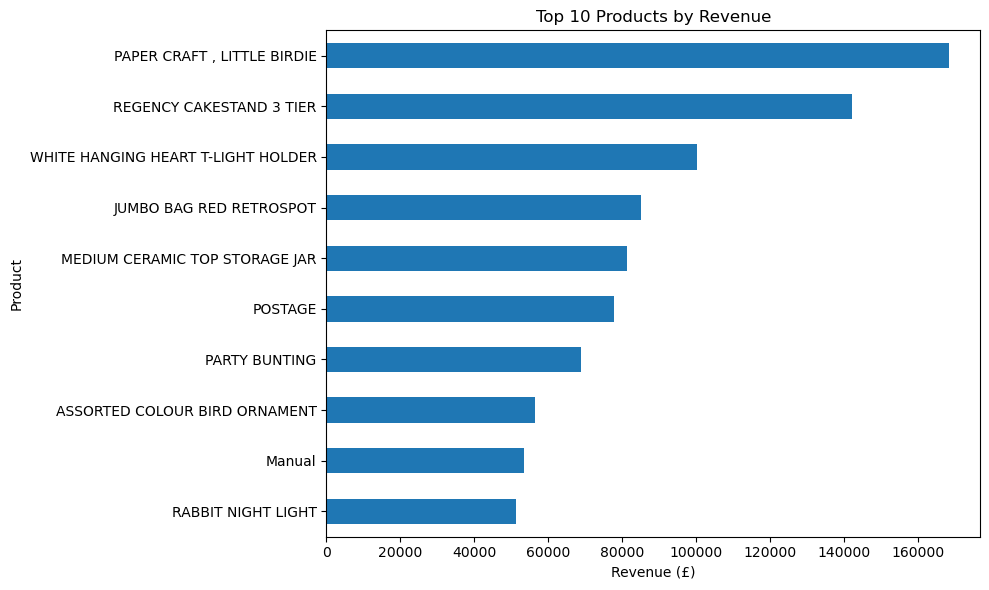

In [78]:
plt.figure(figsize=(10, 6))

top_products.sort_values().plot(kind='barh')

plt.title('Top 10 Products by Revenue')
plt.xlabel('Revenue (£)')
plt.ylabel('Product')
plt.tight_layout()

plt.show()

### Monthly Revenue Analysis

This analysis groups the cleaned transactions by month and calculates the total revenue generated in each month.

It helps us understand how sales changed over time.

In [80]:
monthly_sales = (
    df.groupby('Month')['Revenue']
    .sum()
)

monthly_sales

Month
2010-12     570422.730
2011-01     568101.310
2011-02     446084.920
2011-03     594081.760
2011-04     468374.331
2011-05     677355.150
2011-06     660046.050
2011-07     598962.901
2011-08     644051.040
2011-09     950690.202
2011-10    1035642.450
2011-11    1156205.610
2011-12     517190.440
Freq: M, Name: Revenue, dtype: float64

## Visualization 2 — Monthly Revenue Trend

This line chart shows how revenue changed month by month.

It helps identify periods of increasing or decreasing sales and possible seasonal patterns.

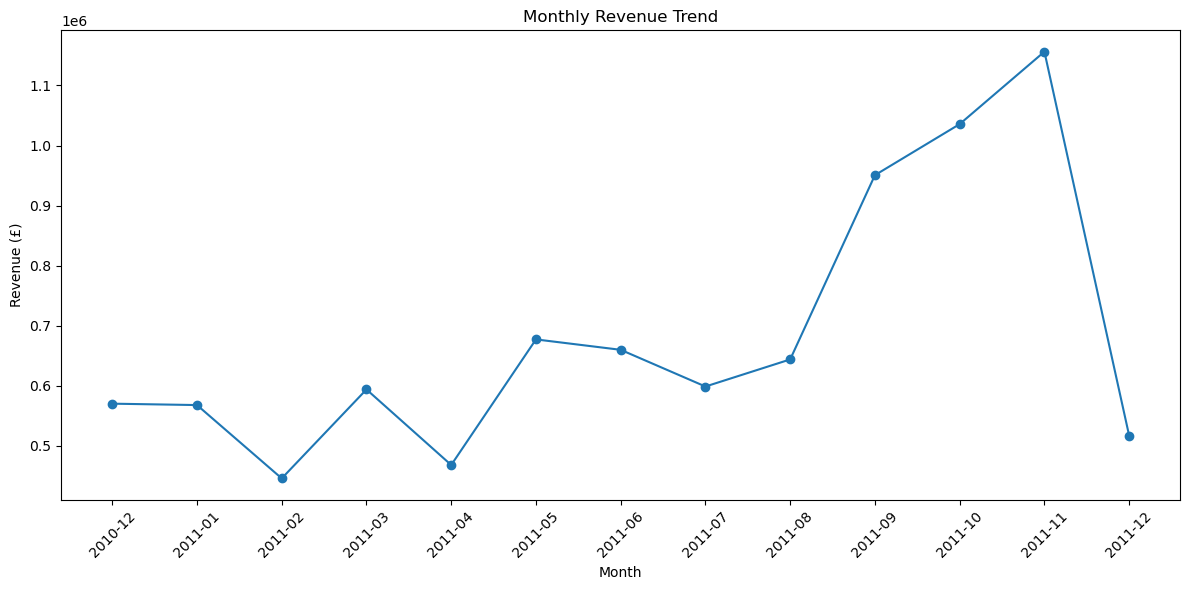

In [82]:
monthly_sales.index = monthly_sales.index.astype(str)

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker='o'
)

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue (£)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Revenue by Country

This analysis groups the transactions by country and calculates total revenue for each country.

It helps identify the most important markets for the business.

In [84]:
country_sales = (
    df.groupby('Country')['Revenue']
    .sum()
    .sort_values(ascending=False)
)

country_sales.head(10)

Country
United Kingdom    7285024.644
Netherlands        285446.340
EIRE               265262.460
Germany            228678.400
France             208934.310
Australia          138453.810
Spain               61558.560
Switzerland         56443.950
Belgium             41196.340
Sweden              38367.830
Name: Revenue, dtype: float64

### Top International Markets

The United Kingdom is excluded to focus specifically on international markets.

This analysis identifies the top 10 countries outside the UK based on revenue.

In [86]:
international_sales = (
    df[df['Country'] != 'United Kingdom']
    .groupby('Country')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

international_sales

Country
Netherlands    285446.34
EIRE           265262.46
Germany        228678.40
France         208934.31
Australia      138453.81
Spain           61558.56
Switzerland     56443.95
Belgium         41196.34
Sweden          38367.83
Japan           37416.37
Name: Revenue, dtype: float64

## Visualization 3 — Top 10 International Markets

This horizontal bar chart compares revenue generated by the top 10 international markets.

It helps identify countries that may provide strong opportunities for international sales and marketing.

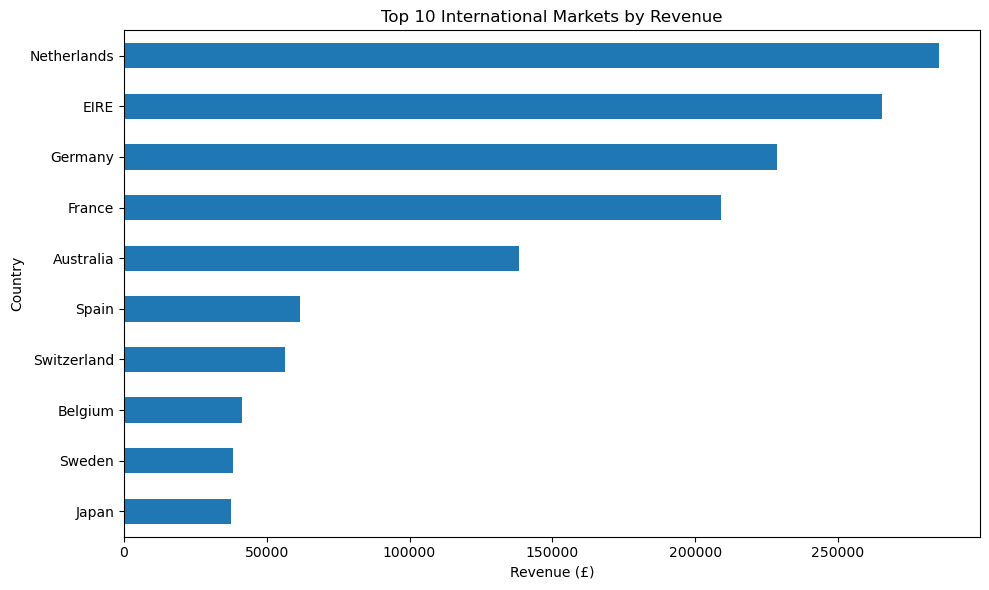

In [88]:
plt.figure(figsize=(10, 6))

international_sales.sort_values().plot(kind='barh')

plt.title('Top 10 International Markets by Revenue')
plt.xlabel('Revenue (£)')
plt.ylabel('Country')
plt.tight_layout()

plt.show()

### Top 10 Best-Selling Products by Quantity

This analysis calculates the total number of units sold for each product.

Unlike revenue analysis, this focuses on product volume and identifies the products sold in the largest quantities.

In [90]:
best_selling_products = (
    df.groupby('Description')['Quantity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

best_selling_products

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54319
JUMBO BAG RED RETROSPOT               46078
WHITE HANGING HEART T-LIGHT HOLDER    36706
ASSORTED COLOUR BIRD ORNAMENT         35263
PACK OF 72 RETROSPOT CAKE CASES       33670
POPCORN HOLDER                        30919
RABBIT NIGHT LIGHT                    27153
MINI PAINT SET VINTAGE                26076
Name: Quantity, dtype: int64

## Visualization 4 — Top 10 Best-Selling Products

This horizontal bar chart shows the 10 products with the highest quantities sold.

It helps identify products with strong customer demand.

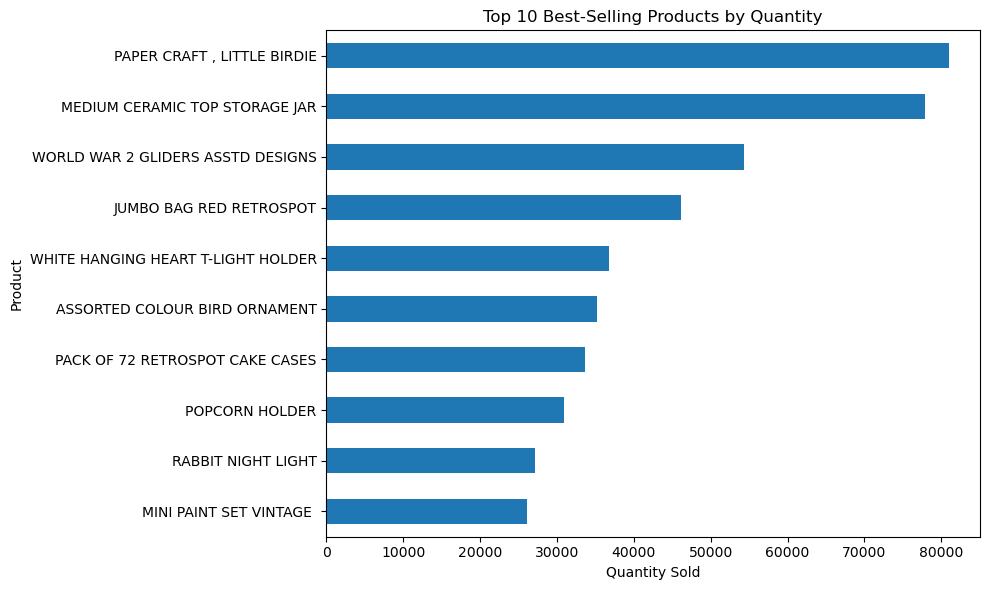

In [92]:
plt.figure(figsize=(10, 6))

best_selling_products.sort_values().plot(kind='barh')

plt.title('Top 10 Best-Selling Products by Quantity')
plt.xlabel('Quantity Sold')
plt.ylabel('Product')
plt.tight_layout()

plt.show()

## Visualization 5 — Distribution of Transaction Revenue

This histogram shows the distribution of transaction-level revenue for transactions below £100.

Limiting the range makes the distribution of typical transactions easier to see without large-value transactions dominating the chart.

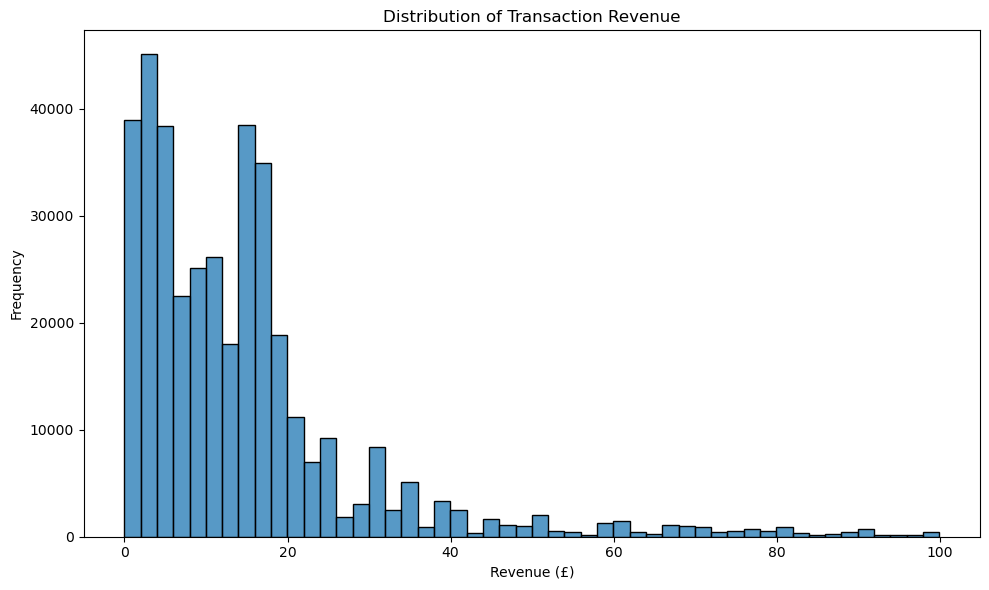

In [94]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df[df['Revenue'] < 100]['Revenue'],
    bins=50
)

plt.title('Distribution of Transaction Revenue')
plt.xlabel('Revenue (£)')
plt.ylabel('Frequency')
plt.tight_layout()

plt.show()

The following insights are based on the cleaned transaction data and the analyses performed in this notebook.

## Key Business Insights

### 1. Strong Overall Sales Performance

The cleaned dataset generated total revenue of approximately **£8.89 million** across **18,532 orders** and **4,338 customers**.

### 2. Top Revenue-Generating Product

**PAPER CRAFT, LITTLE BIRDIE** generated the highest revenue at approximately **£168,469.60**.

### 3. Revenue Growth Toward the End of 2011

Monthly revenue increased significantly during the second half of 2011, with **November 2011** recording the highest revenue of approximately **£1.16 million**.

### 4. Netherlands Is the Leading International Market

After excluding the United Kingdom, the **Netherlands** generated the highest international revenue at approximately **£285,446**, followed by EIRE, Germany, and France.

### 5. High-Volume Products

**PAPER CRAFT, LITTLE BIRDIE** was also the highest-selling product by quantity, with approximately **80,995 units sold**.

### 6. Business Opportunity

The strong performance of international markets such as the Netherlands, EIRE, Germany, and France suggests opportunities to focus marketing and sales efforts on these markets.

## Conclusion

The analysis of the Online Retail dataset provided useful insights into sales performance, product demand, customer activity, and international markets.

After cleaning the data by removing duplicates, missing customer records, invalid quantities, and invalid prices, the dataset contained **392,692 valid transactions**.

The analysis showed that revenue was concentrated among a small group of high-performing products and that sales increased considerably during the later months of 2011. International markets, particularly the Netherlands, EIRE, Germany, and France, also contributed significantly to revenue.

## Recommendations

1. Focus marketing efforts on high-performing products such as PAPER CRAFT, LITTLE BIRDIE and MEDIUM CERAMIC TOP STORAGE JAR.
2. Explore opportunities to increase sales in strong international markets such as the Netherlands, Germany, France, and EIRE.
3. Prepare additional marketing campaigns during periods when sales historically increase.
4. Monitor product demand and inventory levels for high-volume products to avoid stock shortages.
5. Conduct further customer-level analysis to identify high-value customers and opportunities for customer retention.